Importing packages

In [1]:
import kagglehub
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
import warnings
warnings.filterwarnings('ignore')

c:\Users\weron\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Downloading csv file bitcoin historical data 

In [2]:
path = kagglehub.dataset_download("mczielinski/bitcoin-historical-data")

file_path = os.path.join(path, "btcusd_1-min_data.csv")

df = pd.read_csv(file_path)

print(df.head())

100%|██████████| 101M/101M [00:03<00:00, 32.7MB/s] 

Extracting files...


      Timestamp  Open  High   Low  Close  Volume
0  1.325412e+09  4.58  4.58  4.58   4.58     0.0
1  1.325412e+09  4.58  4.58  4.58   4.58     0.0
2  1.325412e+09  4.58  4.58  4.58   4.58     0.0
3  1.325412e+09  4.58  4.58  4.58   4.58     0.0
4  1.325412e+09  4.58  4.58  4.58   4.58     0.0


Showing based information

In [3]:
print(df.shape, df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7522245 entries, 0 to 7522244
Data columns (total 6 columns):
 #   Column     Dtype  
---  ------     -----  
 0   Timestamp  float64
 1   Open       float64
 2   High       float64
 3   Low        float64
 4   Close      float64
 5   Volume     float64
dtypes: float64(6)
memory usage: 344.3 MB
(7522245, 6) None


Checking data for missing values

In [4]:
df.isna().any()

Timestamp    False
Open         False
High         False
Low          False
Close        False
Volume       False
dtype: bool

Checking feature close for negative values - price should be always positive

In [5]:
sum(df["Close"]<0)

0

Changing numeric time entry into timestamps

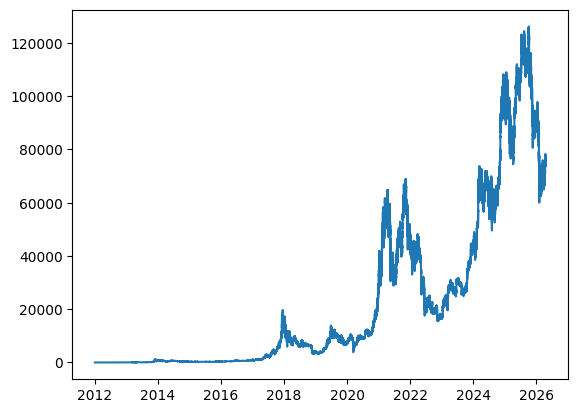

In [6]:
df["Timestamp"]=pd.to_datetime(df["Timestamp"], unit="s")
df = df.set_index("Timestamp").sort_index()
plt.plot(df['Close'])
plt.show()


Calculating hourly data

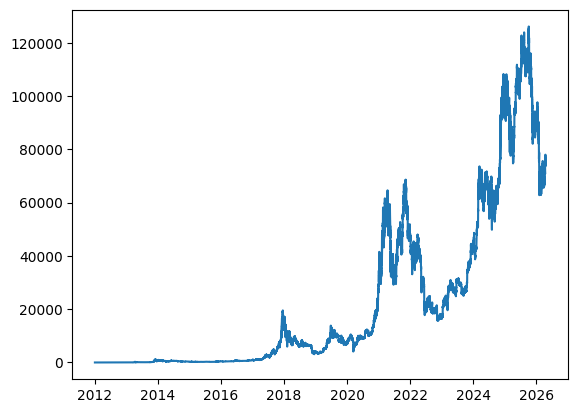

In [7]:
df_hourly = df.resample("1h").agg({
    "Close": "last"
}).dropna()
plt.plot(df_hourly)
plt.show()

Claculating return values in every time step

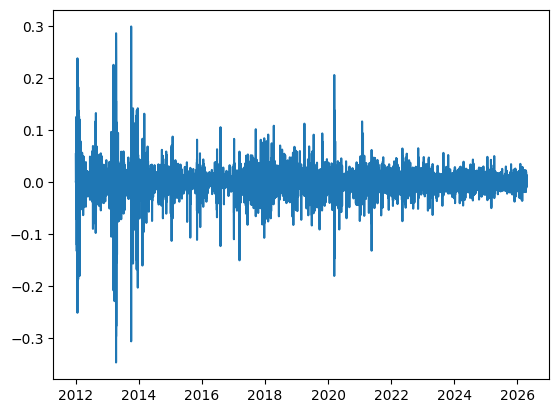

In [8]:
df_hourly["return"] = np.log(df_hourly["Close"]).diff()
df_hourly = df_hourly.dropna()
plt.plot(df_hourly["return"])


Spliting into test and train sets

In [9]:
split_date = "2024-01-01"

df_train = df_hourly.loc[:split_date].copy()
df_test  = df_hourly.loc[split_date:].copy()

Exponential trend smoothing feature "close", Under the hood (with `adjust=False`), it’s the recursive form:

$$
y_t = \alpha x_t + (1 - \alpha) y_{t-1}
$$

where:

- \( x_t \) = `Close` at time *t*  
- \( y_t \) = EMA (`"trend"`)  
- \( $\alpha = \frac{2}{\text{span} + 1} $\)

In [10]:
span =  7*24

df_train["trend"] = df_train["Close"].ewm(span=span, adjust=False).mean()
df_train["detrended"] = df_train["Close"] - df_train["trend"]

df_test["trend"] = df_test["Close"].ewm(span=span, adjust=False).mean()
df_test["detrended"] = df_test["Close"] - df_test["trend"]


Ploting detrended data of close price 

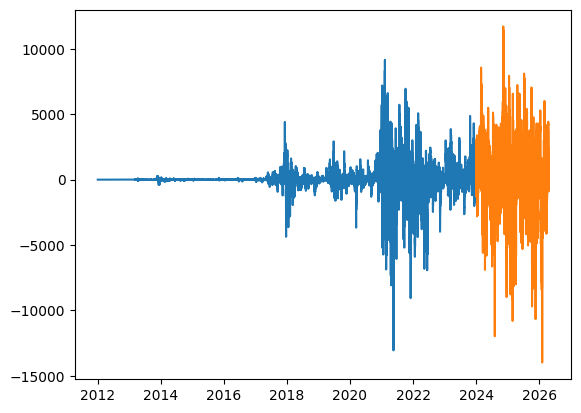

In [11]:
plt.plot(df_train["detrended"])
plt.plot(df_test["detrended"])

Isolating and cuting outliers of returns data

In [12]:
iso = IsolationForest(
    n_estimators=100,
    contamination=0.01,
    random_state=47
)

df_train["outlier"] = iso.fit_predict(df_train[["return"]])
df_train = df_train[df_train["outlier"] == 1].drop(columns=["outlier"])

df_test["outlier"] = iso.predict(df_test[["return"]])
df_test = df_test[df_test["outlier"] == 1].drop(columns=["outlier"])


Second differentiation

In [13]:
df_train["second_return"] = (df_train["return"]).diff()
df_train = df_train.dropna()

df_test["second_return"] = (df_test["return"]).diff()
df_test = df_test.dropna()

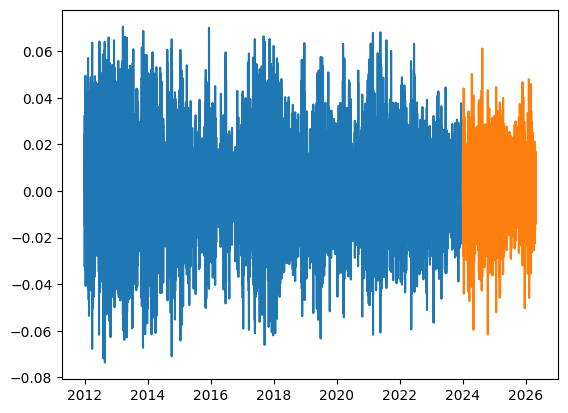

In [14]:
plt.plot(df_train["second_return"])
plt.plot(df_test["second_return"])

Calculating and ploting volatility and mean in weakly windows

In [15]:
df_train_volatility_w = df_train["second_return"].rolling(24*7).std()
df_train_return_mean_w = df_train["second_return"].rolling(24*7).mean()

df_test_volatility_w = df_test["second_return"].rolling(24*7).std()
df_test_return_mean_w = df_test["second_return"].rolling(24*7).mean()

Text(0.5, 1.0, 'weakly window $\\sigma^2$')

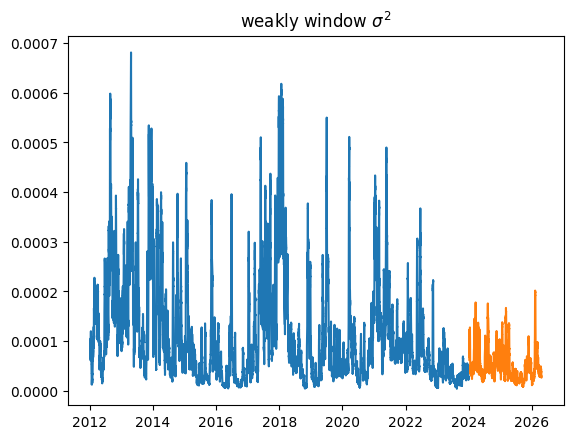

In [16]:
plt.plot((df_train_volatility_w)**2)
plt.plot((df_test_volatility_w)**2)
plt.title(r"weakly window $\sigma^2$")

Text(0.5, 1.0, 'weakly window $\\mu$')

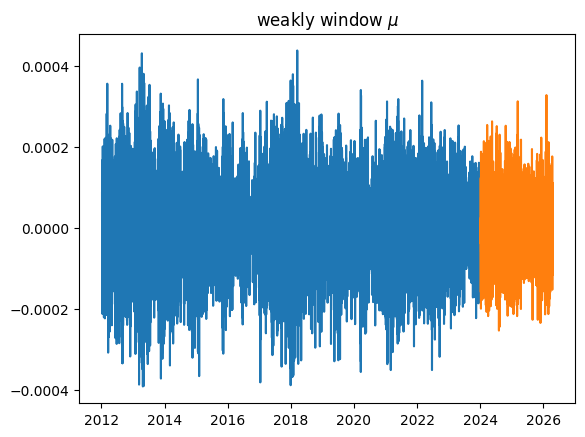

In [17]:
plt.plot(df_train_return_mean_w)
plt.plot(df_test_return_mean_w)
plt.title(r"weakly window $\mu$")

Copy and save data

In [18]:
df_train_final = df_train.copy()
df_test_final  = df_test.copy()

In [19]:
df_test_final.to_csv("test_bitcoin_processed.csv", index=True)
df_train_final.to_csv("train_bitcoin_processed.csv", index=True)

In [20]:
from statsmodels.tsa.stattools import adfuller, kpss

def stationarity_tests(series, name="series"):
    print(f"\n===== Stationarity tests for {name} =====")
    adf_stat, adf_p, _, _, _, _ = adfuller(series)

    print(f"\nADF Test:\nStatistic: {adf_stat:.6f}\np-value:   {adf_p:.6f}")
    if adf_p < 0.05:
        print(" === Reject H0 (unit root) ⇒ likely STATIONARY ===")
    else:
        print(" === Fail to reject H0 ⇒ NON-stationary ===")


    kpss_stat, kpss_p, _, _ = kpss(series, regression="c", nlags="auto")

    print(f"\nKPSS Test:\nStatistic: {kpss_stat:.6f}\np-value:   {kpss_p:.6f}")

    if kpss_p < 0.05:
        print(" === Reject H0 (stationarity) ⇒ NON-stationary ===")
    else:
        print(" === Fail to reject H0 ⇒ likely STATIONARY ===\n\n")

stationarity_tests(df_train_final["return"], "train returns")
stationarity_tests(df_test_final["return"], "test returns")


===== Stationarity tests for train returns =====

ADF Test:
Statistic: -45.401377
p-value:   0.000000
 === Reject H0 (unit root) ⇒ likely STATIONARY ===

KPSS Test:
Statistic: 1.161839
p-value:   0.010000
 === Reject H0 (stationarity) ⇒ NON-stationary ===

===== Stationarity tests for test returns =====


C:\Users\weron\AppData\Local\Temp\ipykernel_17896\3225385604.py:14: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, _, _ = kpss(series, regression="c", nlags="auto")



ADF Test:
Statistic: -143.548946
p-value:   0.000000
 === Reject H0 (unit root) ⇒ likely STATIONARY ===

KPSS Test:
Statistic: 0.312459
p-value:   0.100000
 === Fail to reject H0 ⇒ likely STATIONARY ===




C:\Users\weron\AppData\Local\Temp\ipykernel_17896\3225385604.py:14: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, _, _ = kpss(series, regression="c", nlags="auto")


the resunts of KPSS test on return train set is "Reject H0 (stationarity) ⇒ NON-stationary" so we try with second differentiation. After testing this feature we finally get likely stationaty data on both train and test set in both tests.

In [21]:
stationarity_tests(df_train_final["second_return"], "train second_return")
stationarity_tests(df_test_final["second_return"], "test second_return")


===== Stationarity tests for train second_return =====

ADF Test:
Statistic: -66.664935
p-value:   0.000000
 === Reject H0 (unit root) ⇒ likely STATIONARY ===

KPSS Test:
Statistic: 0.009193
p-value:   0.100000
 === Fail to reject H0 ⇒ likely STATIONARY ===



===== Stationarity tests for test second_return =====


C:\Users\weron\AppData\Local\Temp\ipykernel_17896\3225385604.py:14: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, _, _ = kpss(series, regression="c", nlags="auto")



ADF Test:
Statistic: -37.029007
p-value:   0.000000
 === Reject H0 (unit root) ⇒ likely STATIONARY ===

KPSS Test:
Statistic: 0.008204
p-value:   0.100000
 === Fail to reject H0 ⇒ likely STATIONARY ===




C:\Users\weron\AppData\Local\Temp\ipykernel_17896\3225385604.py:14: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, _, _ = kpss(series, regression="c", nlags="auto")


# 2. Modelling

In [27]:
print(df_train[:-1])

Timestamp
2012-01-01 12:00:00    0.000000
2012-01-01 13:00:00    0.000000
2012-01-01 14:00:00    0.000000
2012-01-01 15:00:00    0.000000
2012-01-01 16:00:00    0.000000
                         ...   
2024-01-01 18:00:00    0.002460
2024-01-01 19:00:00   -0.004335
2024-01-01 20:00:00    0.006256
2024-01-01 21:00:00   -0.004543
2024-01-01 22:00:00    0.003017
Name: second_return, Length: 104155, dtype: float64


Train size: 104156
Test size: 20178


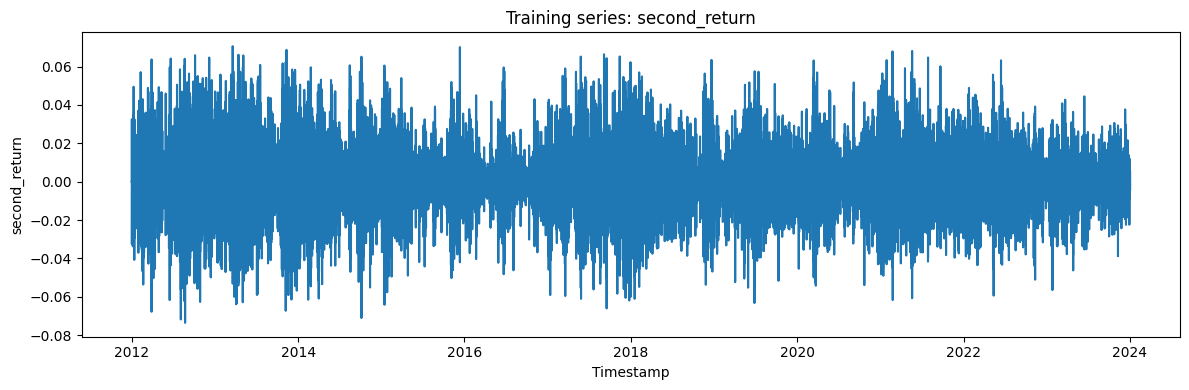

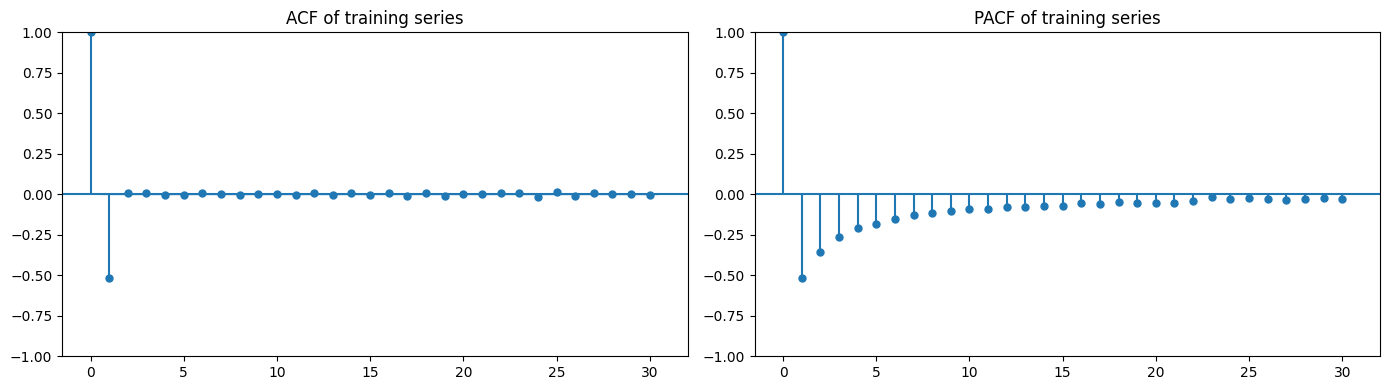


Top ARIMA candidates by AIC:
   p  d  q            AIC
0  0  0  2 -729392.484004
1  2  0  3 -727963.145737
2  0  0  3 -727026.126060
3  1  0  2 -726541.392152
4  3  0  3 -726057.847702
5  1  0  3 -725932.306539
6  2  0  2 -722482.236431
7  3  0  2 -722345.858733
8  2  0  1 -719491.645902
9  3  0  1 -716925.504235

Best ARIMA order: (0, 0, 2)
Best AIC: -729392.4840


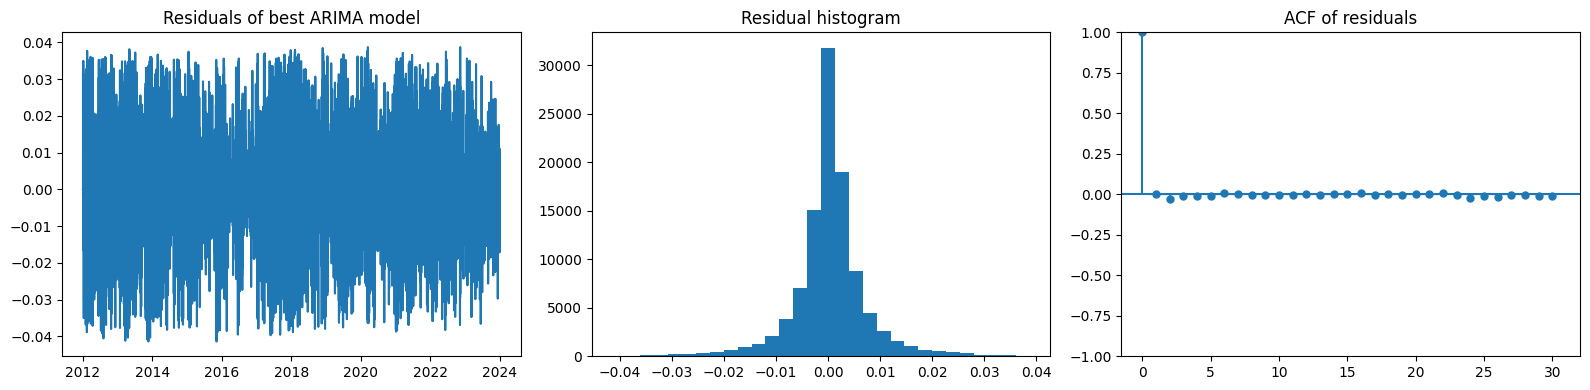

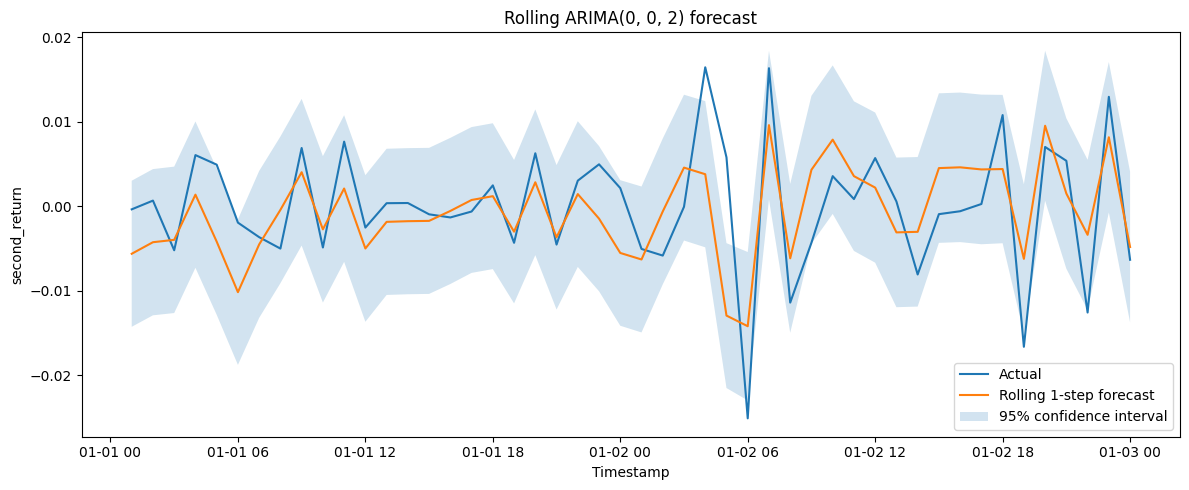

In [32]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error


# =========================
# 1. DATA
# =========================

df_train = df_train_final["second_return"]
df_final = df_test_final["second_return"]

train_series = df_train.astype(float).copy()
test_series = df_final.astype(float).copy()

# pełna seria do późniejszego refitu
full_series = pd.concat([train_series, test_series])

print(f"Train size: {len(train_series)}")
print(f"Test size: {len(test_series)}")


# =========================
# 2. ORIGINAL TRAIN SERIES
# =========================

plt.figure(figsize=(12, 4))
plt.plot(train_series.index, train_series.values)
plt.title("Training series: second_return")
plt.xlabel("Timestamp")
plt.ylabel("second_return")
plt.tight_layout()
plt.show()


# =========================
# 3. ACF AND PACF
# =========================
# Dane są już zróżnicowane i stacjonarne -> d = 0

d = 0
current_series = train_series.copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(current_series.dropna(), lags=30, ax=axes[0])
axes[0].set_title("ACF of training series")

plot_pacf(current_series.dropna(), lags=30, ax=axes[1], method="ywm")
axes[1].set_title("PACF of training series")

plt.tight_layout()
plt.show()


# =========================
# 4. SEARCH FOR p AND q BY AIC
# =========================

best_aic = np.inf
best_order = None
best_model = None
results_summary = []

p_values = range(0, 4)
q_values = range(0, 4)

for p in p_values:
    for q in q_values:
        try:
            model = ARIMA(train_series, order=(p, d, q))
            fitted_model = model.fit()

            aic_value = fitted_model.aic
            results_summary.append((p, d, q, aic_value))

            if aic_value < best_aic:
                best_aic = aic_value
                best_order = (p, d, q)
                best_model = fitted_model

        except Exception:
            continue

results_table = pd.DataFrame(results_summary, columns=["p", "d", "q", "AIC"])
results_table = results_table.sort_values("AIC").reset_index(drop=True)

print("\nTop ARIMA candidates by AIC:")
print(results_table.head(10))

print(f"\nBest ARIMA order: {best_order}")
print(f"Best AIC: {best_aic:.4f}")


# =========================
# 5. RESIDUALS
# =========================

residuals = pd.Series(best_model.resid, index=train_series.index[-len(best_model.resid):])

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(residuals)
axes[0].set_title("Residuals of best ARIMA model")

axes[1].hist(residuals.dropna(), bins=30)
axes[1].set_title("Residual histogram")

plot_acf(residuals.dropna(), lags=30, ax=axes[2])
axes[2].set_title("ACF of residuals")

plt.tight_layout()
plt.show()


# =========================
# 6. ROLLING 1-STEP FORECAST ON TEST SET
# =========================

test_subset = test_series.iloc[:48].copy()   # 48 godzin
history = train_series.astype(float).iloc[-500:].tolist()

predictions = []
lower_bounds = []
upper_bounds = []

for t in range(len(test_subset)):
    model = ARIMA(history, order=best_order)
    fitted_model = model.fit()

    forecast_result = fitted_model.get_forecast(steps=1)
    forecast_mean = np.asarray(forecast_result.predicted_mean).reshape(-1)[0]
    forecast_ci = np.asarray(forecast_result.conf_int(alpha=0.05))

    predictions.append(float(forecast_mean))
    lower_bounds.append(float(forecast_ci[0, 0]))
    upper_bounds.append(float(forecast_ci[0, 1]))

    history.append(float(test_subset.iloc[t]))

rolling_forecast_df = pd.DataFrame({
    "actual": test_subset.values,
    "forecast": predictions,
    "lower_95": lower_bounds,
    "upper_95": upper_bounds
}, index=test_subset.index)

plt.figure(figsize=(12, 5))

plt.plot(rolling_forecast_df.index, rolling_forecast_df["actual"], label="Actual")
plt.plot(rolling_forecast_df.index, rolling_forecast_df["forecast"], label="Rolling 1-step forecast")

plt.fill_between(
    rolling_forecast_df.index,
    rolling_forecast_df["lower_95"],
    rolling_forecast_df["upper_95"],
    alpha=0.2,
    label="95% confidence interval"
)

plt.title(f"Rolling ARIMA{best_order} forecast")
plt.xlabel("Timestamp")
plt.ylabel("second_return")
plt.legend()
plt.tight_layout()
plt.show()
# ====== just predictiong for 7 days
# test_subset = test_series.iloc[:500]   # albo np. [-500:] dla końcówki
# history = train_series.astype(float).tolist()

# predictions = []
# lower_bounds = []
# upper_bounds = []

# for t in range(len(test_subset)):
#     model = ARIMA(history, order=best_order)
#     fitted_model = model.fit()

#     forecast_result = fitted_model.get_forecast(steps=1)

#     forecast_mean = np.asarray(forecast_result.predicted_mean).reshape(-1)[0]
#     forecast_ci = np.asarray(forecast_result.conf_int(alpha=0.05))

#     predictions.append(float(forecast_mean))
#     lower_bounds.append(float(forecast_ci[0, 0]))
#     upper_bounds.append(float(forecast_ci[0, 1]))

#     history.append(float(test_subset.iloc[t]))

# rolling_forecast_df = pd.DataFrame({
#     "actual": test_subset.values,
#     "forecast": predictions,
#     "lower_95": lower_bounds,
#     "upper_95": upper_bounds
# }, index=test_subset.index)


# # =========================
# # 7. METRICS
# # =========================

# rmse = np.sqrt(mean_squared_error(rolling_forecast_df["actual"], rolling_forecast_df["forecast"]))
# mae = mean_absolute_error(rolling_forecast_df["actual"], rolling_forecast_df["forecast"])

# print(f"\nRolling forecast RMSE: {rmse:.6f}")
# print(f"Rolling forecast MAE:  {mae:.6f}")
# print("\nRolling forecast preview:")
# print(rolling_forecast_df.head())


# # =========================
# # 8. FORECAST VS ACTUAL PLOT
# # =========================

# plt.figure(figsize=(12, 5))
# plt.plot(train_series.index, train_series.values, label="Train")
# plt.plot(test_series.index, rolling_forecast_df["actual"], label="Test / Actual")
# plt.plot(test_series.index, rolling_forecast_df["forecast"], label="Rolling 1-step forecast")

# plt.fill_between(
#     test_series.index,
#     rolling_forecast_df["lower_95"],
#     rolling_forecast_df["upper_95"],
#     alpha=0.2,
#     label="95% confidence interval"
# )

# plt.title(f"Rolling ARIMA{best_order} forecast on test set")
# plt.xlabel("Timestamp")
# plt.ylabel("second_return")
# plt.legend()
# plt.tight_layout()
# plt.show()


# # =========================
# # 9. REFIT MODEL ON FULL DATA
# # =========================

# final_model = ARIMA(full_series, order=best_order).fit()


# # =========================
# # 10. FORECAST FOR NEXT DAY
# # =========================
# # Jeśli dane są godzinowe, to następny dzień = 24 kroki naprzód

# future_steps = 24
# future_forecast = final_model.get_forecast(steps=future_steps)

# future_mean = np.asarray(future_forecast.predicted_mean).reshape(-1)
# future_conf_int = np.asarray(future_forecast.conf_int(alpha=0.05))

# future_index = pd.date_range(
#     start=full_series.index[-1] + pd.Timedelta(hours=1),
#     periods=future_steps,
#     freq="H"
# )

# forecast_next_day = pd.DataFrame({
#     "forecast": future_mean,
#     "lower_95": future_conf_int[:, 0],
#     "upper_95": future_conf_int[:, 1]
# }, index=future_index)

# print("\nForecast for next day (24 hours ahead):")
# print(forecast_next_day)


# # =========================
# # 11. NEXT DAY FORECAST PLOT
# # =========================

# plt.figure(figsize=(12, 5))
# plt.plot(full_series.index[-200:], full_series.iloc[-200:], label="Historical second_return")
# plt.plot(forecast_next_day.index, forecast_next_day["forecast"], label="Next day forecast")

# plt.fill_between(
#     forecast_next_day.index,
#     forecast_next_day["lower_95"],
#     forecast_next_day["upper_95"],
#     alpha=0.2,
#     label="95% confidence interval"
# )

# plt.title(f"ARIMA{best_order} - forecast for next 24 hours")
# plt.xlabel("Timestamp")
# plt.ylabel("second_return")
# plt.legend()
# plt.tight_layout()
# plt.show()